# MNIST classification with KerasTuner HyperModels
## Table of Contents
- Summary
- Importing necessary Libraries
- Loading the data
- Exploratory Data Analysis
- Model Development
- Submission

## Summary
In this notebook I will build a MNIST Classifer based on KerasTuner HyperModels. KerasTuner offers two implementations:
- HyperResNet
- HyperXception

You can also make your own implementation. You can find more details [here](https://keras.io/api/keras_tuner/hypermodels/).
## Importing necessary Libraries

In [1]:
!pip install keras-tuner --upgrade

     |████████████████████████████████| 97 kB 782 kB/s 
  Attempting uninstall: keras-tuner
    Found existing installation: keras-tuner 1.0.2
    Uninstalling keras-tuner-1.0.2:
      Successfully uninstalled keras-tuner-1.0.2


In [2]:
import numpy as np
import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
import keras_tuner as kt

## Loading the data

In [3]:
train_pd = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test_pd = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')
train = np.array(train_pd)
test = np.array(test_pd)
train_images = train[:, 1:].reshape((train.shape[0], 28, 28, 1))
train_labels = train[:, 0].astype(np.uint8)
test_images = test.reshape((test.shape[0], 28, 28, 1))

## Exploratory Data Analysis

In [4]:
train_pd.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train_pd.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


**Correlation Score**

In [6]:
correlation_score = train_pd.corr()

In [7]:
correlated_features = correlation_score["label"].sort_values(ascending=False).dropna()
correlated_columns = list(correlated_features[correlated_features.abs() > 0.2].index)
correlated_columns.remove("label")
print(correlated_columns)

['pixel381', 'pixel409', 'pixel436', 'pixel408', 'pixel464', 'pixel437', 'pixel353', 'pixel354', 'pixel382', 'pixel380', 'pixel263', 'pixel492', 'pixel290', 'pixel326', 'pixel712', 'pixel262', 'pixel713', 'pixel465', 'pixel714', 'pixel711', 'pixel236', 'pixel264', 'pixel410', 'pixel291', 'pixel463', 'pixel715', 'pixel435', 'pixel235', 'pixel289', 'pixel685', 'pixel716', 'pixel491', 'pixel684', 'pixel318', 'pixel710', 'pixel686', 'pixel325', 'pixel261', 'pixel317', 'pixel687', 'pixel717', 'pixel431', 'pixel688', 'pixel237', 'pixel355', 'pixel520', 'pixel683', 'pixel593', 'pixel570', 'pixel125', 'pixel525', 'pixel415', 'pixel524', 'pixel128', 'pixel512', 'pixel413', 'pixel497', 'pixel441', 'pixel469', 'pixel152', 'pixel442', 'pixel126', 'pixel453', 'pixel127', 'pixel387', 'pixel359', 'pixel322', 'pixel455', 'pixel158', 'pixel623', 'pixel599', 'pixel414', 'pixel358', 'pixel153', 'pixel565', 'pixel386', 'pixel626', 'pixel540', 'pixel454', 'pixel569', 'pixel157', 'pixel594', 'pixel624', 'pi

**Label Distribution**

<AxesSubplot:ylabel='label'>

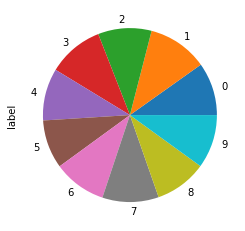

In [8]:
train_pd.groupby("label")["label"].count().plot(kind="pie")

**Mean image for different labels**

Calcuate mean image for different labels, they look exactly the label they belong to.

(28, 280)


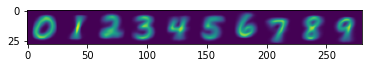

In [9]:
mean_images = [np.mean(train_images[train_labels == i].reshape(-1, 28, 28), axis=0) for i in range(10)]
concat_image = np.concatenate(mean_images, axis=1)
print(concat_image.shape)
plt.imshow(concat_image)
plt.show()

## Model Development

In [10]:
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels)

In [11]:
train_labels = keras.utils.to_categorical(train_labels, num_classes=10)
val_labels = keras.utils.to_categorical(val_labels, num_classes=10)

In [12]:
tuner = kt.RandomSearch(
    kt.applications.HyperResNet(input_shape=(28, 28, 1), classes=10),
    objective='val_loss',
    max_trials=5)

In [13]:
tuner.search(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Trial 5 Complete [00h 07m 37s]
val_loss: 0.6571820378303528

Best val_loss So Far: 0.08015197515487671
Total elapsed time: 00h 36m 18s


In [14]:
best_model = tuner.get_best_models()[0]

In [15]:
best_model.summary()

Model: "ResNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 28, 28, 1)]  0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 34, 34, 1)    0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 14, 14, 64)   3200        conv1_pad[0][0]                  
__________________________________________________________________________________________________
pool1_pad (ZeroPadding2D)       (None, 16, 16, 64)   0           conv1_conv[0][0]                 
_____________________________________________________________________________________________

## Submission

In [16]:
test_labels = np.argmax(best_model.predict(test_images), axis=-1)
print(test_labels.shape)

(28000,)


In [17]:
sample_submission = pd.read_csv("/kaggle/input/digit-recognizer/sample_submission.csv")
sample_submission["Label"] = test_labels
sample_submission.to_csv("submission.csv", index=False)

In [18]:
image_ids = np.arange(1, test_labels.shape[0]+1)
result = np.concatenate((image_ids.reshape(image_ids.shape[0], 1), test_labels.reshape(test_labels.shape[0], 1)), axis=1)
df = pd.DataFrame(result, columns=["ImageId", "Label"], dtype='int')
df.to_csv("submission.csv", index=False)